In [1]:
from utils import obtain_run, get_config, scale_rew, load_proxy_sol
from gflownet.utils.sqlite_log import read_all_results

In [18]:
import pandas as pd
data_url = r"https://raw.githubusercontent.com/CesareWang/Predictors-for-15-Environmental-Endpoints/main/predictors/data/SW.csv"
sol_data = list(pd.read_csv(data_url, index_col=0)["active"])
ids = ["fm_experiment(lr=1e-4)"]
for id in ids:
    run_path = obtain_run(id)
    # config = get_config(id)
    results = read_all_results(run_path / "final")
    #results_train = read_all_results(run_path / "train")    

In [3]:
from rdkit import Chem
from rdkit.Chem import MACCSkeys
from rdkit import DataStructs


def generate_maccs_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    fingerprint = MACCSkeys.GenMACCSKeys(mol)
    return fingerprint


smiles = results["smi"]
maccs_fingerprints = [generate_maccs_fingerprint(smile) for smile in smiles]

import numpy as np

# Compute pairwise Tanimoto similarities
n_samples = len(maccs_fingerprints)
similarity_matrix = np.zeros((n_samples, n_samples))

for i in range(n_samples):
    for j in range(i, n_samples):
        similarity = DataStructs.TanimotoSimilarity(maccs_fingerprints[i], maccs_fingerprints[j])
        similarity_matrix[i, j] = similarity
        similarity_matrix[j, i] = similarity  # Symmetric matrix

# Calculate average pairwise similarity
# Extract upper triangular part of the similarity matrix (excluding diagonal)
upper_triangular = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]
# Calculate average and standard deviation
average_similarity = np.mean(upper_triangular)

KeyboardInterrupt: 

In [15]:
average_similarity

0.8993535353535353

In [4]:
smiles

0       c1ccc2cc(-c3cc(-c4cc(-c5cc(-c6cc(-c7cccc8ccccc...
1       c1ccc2cc(-c3cc(-c4ccc(-c5cc(-c6ccc7ccccc7c6)c6...
2       O=[PH](O)c1cc(-c2cc(-c3ccccc3-c3cc(-c4ccc5cccc...
3       O=[SH](=O)c1cc(-c2cc(-c3cc(-c4cc(-c5cccc6ccccc...
4       c1ccc2cc(-c3ccc(-c4cc(-c5cccc6ccccc56)c5ccccc5...
                              ...                        
6395    CN(C)c1ccc(-c2cc(-c3cccc4ccccc34)c(-c3ccc4cccc...
6396    CC(C)(O)c1cc(-c2cc(-c3cc([PH](=O)O)cc4ccccc34)...
6397    O=C(Nc1cc(-c2cc(-c3cccc4ccccc34)c3ccccc3c2)c2c...
6398    c1ccc(-c2cc(-c3cccc(-c4ccc(-c5ccc6ccccc6c5)cc4...
6399    c1ccc2cc(-c3cc(-c4cc(-c5cc(-c6cc(-c7cccc8ccccc...
Name: smi, Length: 6400, dtype: object

In [10]:
average_similarity

0.390975727703114

In [4]:
average_similarity

0.40421335267531366

In [5]:
sorted_results

2155    c1ccc2cc(-c3cc(-c4cc(-c5cc(-c6cc(-c7ccc8ccccc8...
2028    c1ccc2cc(-c3cc(-c4cc(-c5cc(-c6cc(-c7ccc8ccccc8...
373     c1ccc2c(-c3cc(-c4cc(-c5cc(-c6cc(-c7cccc8ccccc7...
4168    c1ccc2cc(-c3cc(-c4cc(-c5cc(-c6cc(-c7cccc8ccccc...
1932    c1ccc2c(-c3cc(-c4cc(-c5cccc6ccccc56)c5ccccc5c4...
                              ...                        
2085    c1ccc2cc(-c3ccc(-c4cc(-c5ccc6ccccc6c5)c5ccccc5...
5885    c1ccc2cc(-c3cc(-c4cc(-c5cc(C6CCCCC6)cc6ccccc56...
5450    c1cc(-c2ccc(-c3ccc4ccccc4c3)c(-c3cccc4ccccc34)...
2341    c1cc(-c2ccc3ccccc3c2)cc(-c2cccc(-c3ccc4ccccc4c...
3120    c1ccc(-c2ccc3ccccc3c2)c(-c2ccc(-c3cc(-c4ccccc4...
Name: smi, Length: 1000, dtype: object

In [12]:
sorted_results = results.sort_values(by="r", ascending=False)
sorted_results = sorted_results.iloc[:100]["smi"]

In [ ]:
sorted_results.iloc["smi"]

'CC(C)=Cc1ccccc1-c1ccc(-c2ccccn2)c(-c2ccccc2)c1-c1cccc2ccccc12'

### Fragment checker

In [1]:
import pandas as pd
data_url = r"https://raw.githubusercontent.com/CesareWang/Predictors-for-15-Environmental-Endpoints/main/predictors/data/SW.csv"
smiles_data = list(pd.read_csv(data_url, index_col=0)["smiles"])

In [18]:
FRAGMENTS: list[tuple[str, list[int]]] = [
    ("Br", [0]),
    ("C", [0]),
    ("C#N", [0]),
    ("C1=CCCCC1", [0, 2, 3]),
    ("C1=CNC=CC1", [0, 2]),
    ("C1CC1", [0]),
    ("C1CCCC1", [0]),
    ("C1CCCCC1", [0, 1, 2, 3, 4, 5]),
    ("C1CCNC1", [0, 2, 3, 4]),
    ("C1CCNCC1", [0, 1, 3]),
    ("C1CCOC1", [0, 1, 2, 4]),
    ("C1CCOCC1", [0, 1, 2, 4, 5]),
    ("C1CNCCN1", [2, 5]),
    ("C1COCCN1", [5]),
    ("C1COCC[NH2+]1", [5]),
    ("C=C", [0, 1]),
    ("C=C(C)C", [0]),
    ("C=CC", [0, 1]),
    ("C=N", [0]),
    ("C=O", [0]),
    ("CC", [0, 1]),
    ("CC(C)C", [1]),
    ("CC(C)O", [1]),
    ("CC(N)=O", [2]),
    ("CC=O", [1]),
    ("CCC", [1]),
    ("CCO", [1]),
    ("CN", [0, 1]),
    ("CNC", [1]),
    ("CNC(C)=O", [0]),
    ("CNC=O", [0, 2]),
    ("CO", [0, 1]),
    ("CS", [0]),
    ("C[NH3+]", [0]),
    ("C[SH2+]", [1]),
    ("Cl", [0]),
    ("F", [0]),
    ("FC(F)F", [1]),
    ("I", [0]),
    ("N", [0]),
    ("N=CN", [1]),
    ("NC=O", [0, 1]),
    ("N[SH](=O)=O", [1]),
    ("O", [0]),
    ("O=CNO", [1]),
    ("O=CO", [1]),
    ("O=C[O-]", [1]),
    ("O=PO", [1]),
    ("O=P[O-]", [1]),
    ("O=S=O", [1]),
    ("O=[NH+][O-]", [1]),
    ("O=[PH](O)O", [1]),
    ("O=[PH]([O-])O", [1]),
    ("O=[SH](=O)O", [1]),
    ("O=[SH](=O)[O-]", [1]),
    ("O=c1[nH]cnc2[nH]cnc12", [3, 6]),
    ("O=c1[nH]cnc2c1NCCN2", [8, 3]),
    ("O=c1cc[nH]c(=O)[nH]1", [2, 4]),
    ("O=c1nc2[nH]c3ccccc3nc-2c(=O)[nH]1", [8, 4, 7]),
    ("O=c1nccc[nH]1", [3, 6]),
    ("S", [0]),
    ("c1cc[nH+]cc1", [1, 3]),
    ("c1cc[nH]c1", [0, 2]),
    ("c1ccc2[nH]ccc2c1", [6]),
    ("c1ccc2ccccc2c1", [0, 2]),
    ("c1ccccc1", [0, 1, 2, 3, 4, 5]),
    ("c1ccncc1", [0, 1, 2, 4, 5]),
    ("c1ccsc1", [2, 4]),
    ("c1cn[nH]c1", [0, 1, 3, 4]),
    ("c1cncnc1", [0, 1, 3, 5]),
    ("c1cscn1", [0, 3]),
    ("c1ncc2nc[nH]c2n1", [2, 6]),
]

In [19]:
len(FRAGMENTS)

72

In [5]:
from rdkit import Chem

frag_list = []
for fragment in FRAGMENTS:
    frag = fragment[0]
    exist = 0
    for smiles in smiles_data:
        fr = Chem.MolFromSmiles(frag)
        larger_mol = Chem.MolFromSmiles(smiles)
        if larger_mol.HasSubstructMatch(fr):
            exist+=1
    frag_list.append((frag, exist))
    print(f"Fragment: {frag}, Count: {exist}")    

Fragment: Br, Count: 208
Fragment: C, Count: 5268
Fragment: C#N, Count: 119
Fragment: C1=CCCCC1, Count: 100
Fragment: C1=CNC=CC1, Count: 0
Fragment: C1CC1, Count: 66
Fragment: C1CCCC1, Count: 145
Fragment: C1CCCCC1, Count: 220
Fragment: C1CCNC1, Count: 43
Fragment: C1CCNCC1, Count: 81
Fragment: C1CCOC1, Count: 62
Fragment: C1CCOCC1, Count: 58
Fragment: C1CNCCN1, Count: 42
Fragment: C1COCCN1, Count: 23
Fragment: C1COCC[NH2+]1, Count: 0
Fragment: C=C, Count: 544
Fragment: C=C(C)C, Count: 223
Fragment: C=CC, Count: 521
Fragment: C=N, Count: 363
Fragment: C=O, Count: 2516
Fragment: CC, Count: 4388
Fragment: CC(C)C, Count: 1031
Fragment: CC(C)O, Count: 748
Fragment: CC(N)=O, Count: 596
Fragment: CC=O, Count: 2115
Fragment: CCC, Count: 2764
Fragment: CCO, Count: 2431
Fragment: CN, Count: 2289
Fragment: CNC, Count: 1302
Fragment: CNC(C)=O, Count: 508
Fragment: CNC=O, Count: 758
Fragment: CO, Count: 3121
Fragment: CS, Count: 621
Fragment: C[NH3+], Count: 332
Fragment: C[SH2+], Count: 0
Fragmen

In [11]:
for frag in frag_list:
    if frag[1] < 25:
        print(frag[0], frag[1])

C1=CNC=CC1 0
C1COCCN1 23
C1COCC[NH2+]1 0
C[SH2+] 0
O=CNO 18
O=C[O-] 0
O=P[O-] 0
O=[PH]([O-])O 0
O=[SH](=O)[O-] 0
O=c1[nH]cnc2c1NCCN2 0
O=c1nc2[nH]c3ccccc3nc-2c(=O)[nH]1 1
c1cc[nH+]cc1 11
c1ccc2[nH]ccc2c1 16


In [19]:
sorted_results = results.sort_values(by="r", ascending=False)
sorted_results = sorted_results.drop_duplicates(subset="smi")

In [20]:
sorted_results

,smi,r,fr_0,ci_beta
4143,c1cc(-c2ccc3ccccc3c2)cc(-c2ccc(C3CCCC3)cc2-c2c...,1.018196,1.018196,4.0
3306,c1cc(-c2cc(C3CCCC(c4ccc(C5CCCCC5)cc4)C3)c3cccc...,1.001519,1.001519,4.0
6078,c1ccc2cc(-c3ccc(C4CCCC(C5CCCCC5)C4c4cc(C5CCCCC...,1.000947,1.000947,4.0
759,c1ccc(N2CCCCC2)c(-c2nccc(-c3cc(-c4cc(-c5ccc6cc...,0.991346,0.991346,4.0
739,c1ccc(C2CC(c3ccc4ccccc4c3)CCC2c2cc(-c3ccc4cccc...,0.986111,0.986111,4.0
...,...,...,...,...
3529,[NH3+]C[PH](=O)O,0.092196,0.092196,4.0
130,CC(O)N(C)C,0.084311,0.084311,4.0
2432,CC(O)F,0.073066,0.073066,4.0
594,NC[NH3+],0.056354,0.056354,4.0


/home/john-savvas/Documents/thesis_code/gflownet/venv/lib/python3.10/site-packages/rdkit/Chem/Draw/IPythonConsole.py:343: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


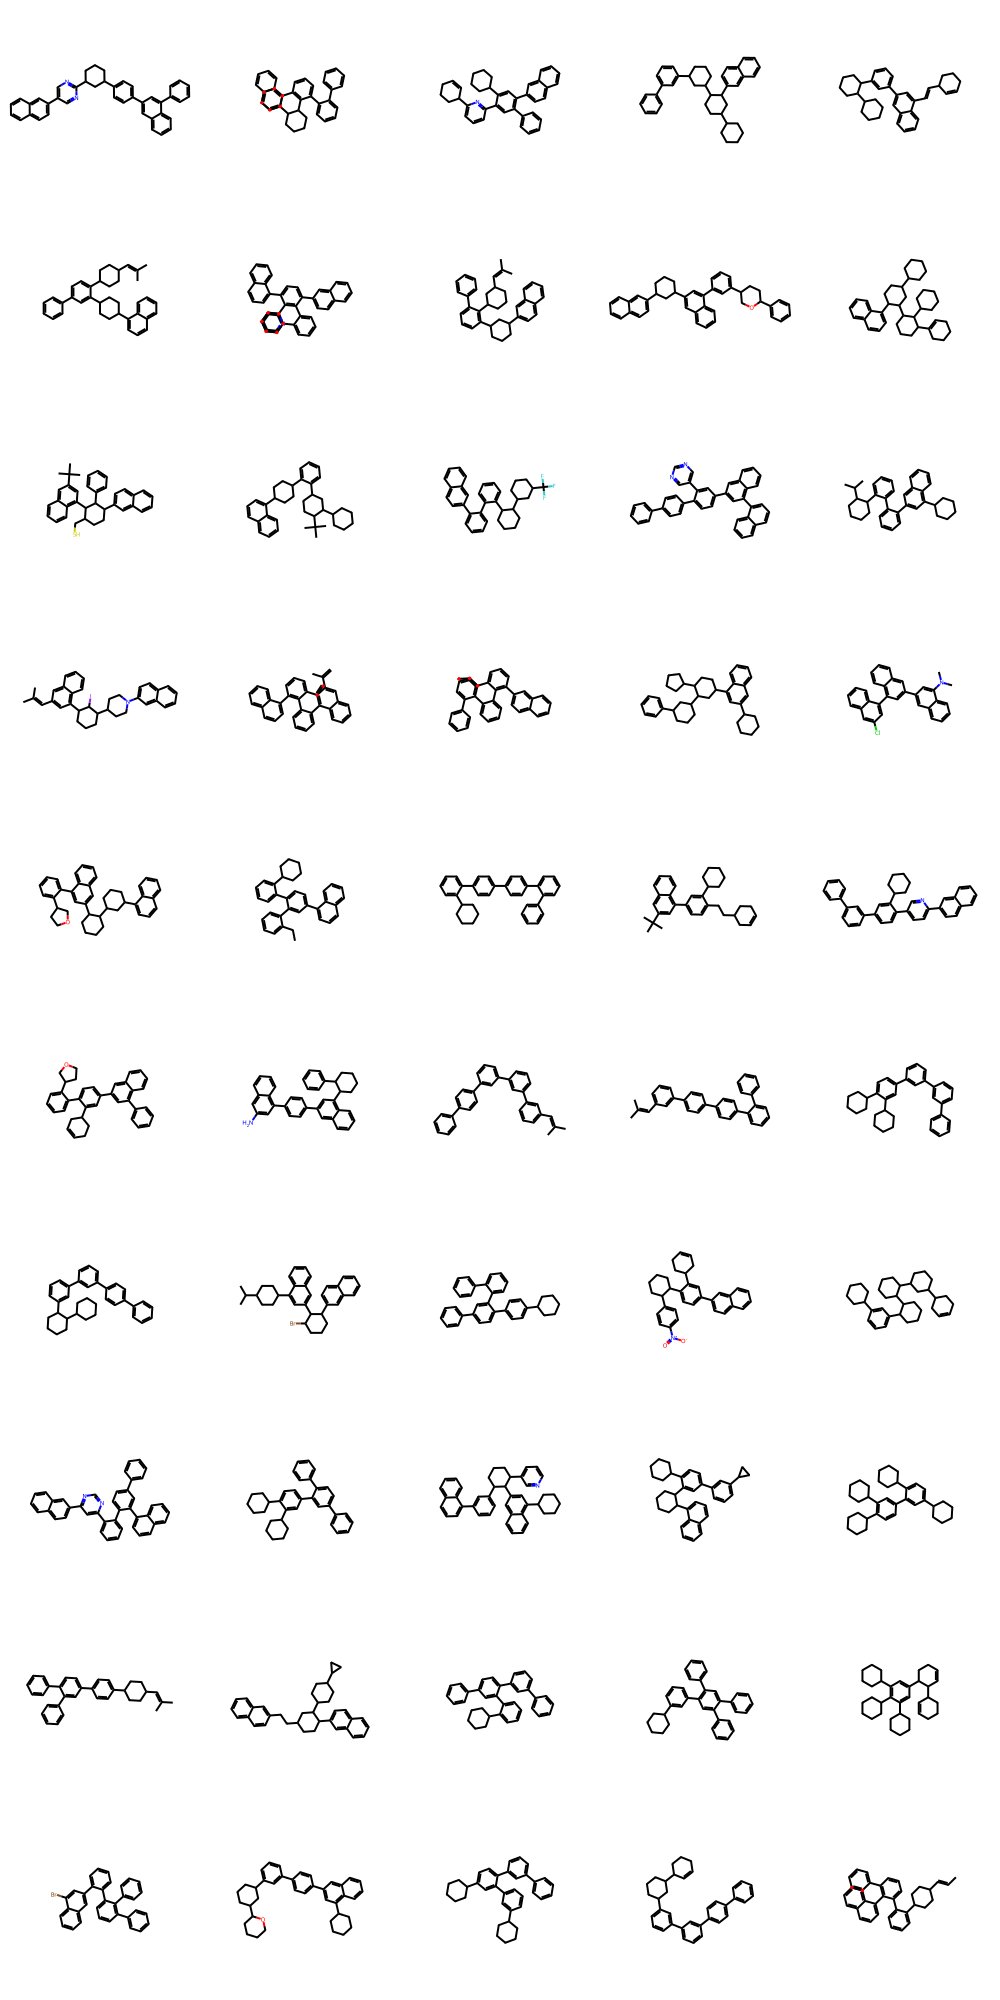

In [22]:
from rdkit.Chem import Draw
from rdkit import Chem
# Select the first 10 molecules from sorted_results
molecules_to_plot = [Chem.MolFromSmiles(smiles) for smiles in sorted_results["smi"].iloc[50:]]

# Plot the molecules
img = Draw.MolsToGridImage(molecules_to_plot, molsPerRow=5, subImgSize=(200, 200))
img

In [15]:
sorted_results["smi"][0]

'c1ccc2cc(-c3cc(-c4cc(-c5cc(-c6cc(-c7cccc8ccccc78)cc7ccccc67)c6ccccc6c5)cc5ccccc45)c4ccccc4c3)ccc2c1'